## Installing Librarires

In [1]:


import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\TEJASWI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TEJASWI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\TEJASWI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Importing Libraries

In [2]:
import numpy as np 
import pandas as pd
import nltk
import re
import contractions
from tqdm import tqdm
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
import sys
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


## Setting Data Path from Kaggle

In [3]:
import kagglehub
data_path = kagglehub.dataset_download('suchintikasarkar/sentiment-analysis-for-mental-health')

print("Printing the complete kaggle dataSet.")

Printing the complete kaggle dataSet.


## Raw Text Exploratory Data Analysis (EDA)
- Load the dataset and inspect its structure (shape, columns, data types)
- Check for missing values in text and label columns
- Identify duplicate records in the dataset
- Analyze class distribution and calculate percentage imbalance
- Compute text length and word count statistics on raw text
- Visualize label distribution for imbalance detection
- Display sample raw texts for manual inspection

In [4]:
df = pd.DataFrame()
DATA_PATH = os.path.join(data_path, "Combined Data.csv")
df = pd.read_csv(DATA_PATH)

In [5]:
print("\nSample Raw Text:")
print(df['statement'].iloc[15])


Sample Raw Text:
Every time I wake up, I'm definitely nervous and excited, until when are you going to try ™‚


In [6]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (53043, 3)


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [7]:
df.sample(10)

,Unnamed: 0,statement,status
6377,6377,"Mirin! Risa! Found! Hey! Nemo, Perorin! Admire...",Normal
22910,22910,My brain feels so old and tired I am only 18 a...,Depression
42557,42557,saffron why not,Normal
41044,41044,lounisdell stats feed i don t think a country ...,Depression
20432,20432,"My boyfriend is a cop, we live in sweeden wher...",Depression
26676,26676,Everyone fucking disappears without a trace or...,Suicidal
2846,2846,"Ya Allah, I can't imagine if I'm a mulfanðŸ'¸",Normal
49739,49739,What do you do when people hurt you I've been ...,Bipolar
11045,11045,I am writing a story and my character is a man...,Depression
52130,52130,Any alternatives to hydroxyzine? At the moment...,Anxiety


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nClass Distribution:")
print(df['status'].value_counts())

print("\nClass Distribution (%):")
print(df['status'].value_counts(normalize=True) * 100)


Missing Values:
Unnamed: 0      0
statement     362
status          0
dtype: int64

Duplicate Rows: 0

Class Distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

Class Distribution (%):
status
Normal                  30.825934
Depression              29.040590
Suicidal                20.083706
Anxiety                  7.329902
Bipolar                  5.423901
Stress                   5.031767
Personality disorder     2.264201
Name: proportion, dtype: float64


In [9]:
df['text_length'] = df['statement'].apply(lambda x: len(str(x)))
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))

print("\nText Length Statistics:")
print(df[['text_length', 'word_count']].describe())


Text Length Statistics:
        text_length    word_count
count  53043.000000  53043.000000
mean     574.784816    112.393285
std      844.707198    163.436684
min        2.000000      1.000000
25%       77.000000     15.000000
50%      313.000000     61.000000
75%      748.000000    147.500000
max    32759.000000   6300.000000


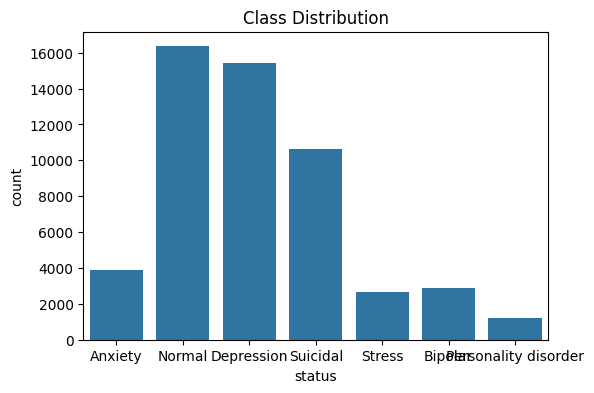

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df)
plt.title("Class Distribution")
plt.show()

## NLP Resource Initialization & Setup
- Initialize placeholders for spaCy model, stopwords, and lemmatizer
- Download required NLTK resources (WordNet, Stopwords, Punkt)
- Create English stopword set
- Initialize WordNet Lemmatizer
- Verify successful NLTK resource loading
- Load spaCy English model (en_core_web_sm)
- Enable spaCy-based lemmatization if available
- Handle errors gracefully with fallback mechanisms
- Ensure stable and robust NLP environment before preprocessing

In [11]:
nlp = None
stop_words = set()
lemmatizer = None

try:
    nltk.download('wordnet', quiet = True, raise_on_error = True)
    nltk.download('stopwords', quiet = True, raise_on_error = True)
    nltk.download('punkt', quiet=True, raise_on_error=True)

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    _ = lemmatizer.lemmatize("test") # Dummy call to ensure WordNet is properly loaded
    print("NLTK resources (stopwords, wordnet) loaded successfully.")

except Exception as e:
    print(f"NLTK resource download or initialization error: {e}.")
    print("Stopword removal or NLTK Lemmatization might be affected or skipped.")

try:
    nlp = spacy.load("en_core_web_sm")
    print("spaCy model 'en_core_web_sm' loaded successfully.")
except Exception as e:
    print(f"spaCy model ('en_core_web_sm') loading error: {e}. spaCy-based lemmatization will not be available.")
    nlp = None # Ensure nlp is None if loading fails

NLTK resources (stopwords, wordnet) loaded successfully.
spaCy model 'en_core_web_sm' loaded successfully.


## Data Loading & Preparation
- Initialize dataset path, column names, test size (20%), and random seed
- Load dataset from CSV with fallback dummy data if file is missing
- Clean column names and remove unnecessary index column
- Validate required text and label columns
- Handle missing values and ensure correct data types
- Extract unique labels and create numerical label mapping
- Separate features (X) and target (y)
- Perform stratified train-test split with fallback handling
- Display dataset sizes and confirm successful setup

In [12]:
print("\n Data Loading...")
df = pd.DataFrame()


DATA_PATH = os.path.join(data_path, "Combined Data.csv")
TEXT_COLUMN = 'statement'
LABEL_COLUMN = 'status'

TEST_SIZE = 0.2  ## Test size is 20%

# General
SEED = 42

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"Error: Dataset not found at '{DATA_PATH}'. Using dummy data for demonstration.")
    # Dummy data for robust execution if actual data is missing
    df = pd.DataFrame({
        TEXT_COLUMN: [
            "I feel incredibly sad and overwhelmed today #depression",
            "This is a fantastic day, I'm so happy and energetic! www.example.com",
            "Just a regular, normal kind of day. Nothing special to report @user.",
            "Feeling very down and can't seem to cope with anything!!! #anxiety",
            "Excited about the future and all the possibilities! Life is good.",
            "LOL, this is gr8! I can't stop laughing.",
            "My anxiety peaks whenever I think about exams. It's debilitating.",
            "Making progress with my therapy for bipolar disorder. It's a journey.",
            "Sometimes the stress is just too much to handle. I need a break.",
            "Suicidal ideation is a heavy burden. Seeking help is important.",
            "Living with a personality disorder presents unique daily challenges."
        ],
        LABEL_COLUMN: ["Depression", "Normal", "Normal", "Anxiety", "Normal", "Normal",
                       "Anxiety", "Bipolar", "Stress", "Suicidal", "Personality disorder"]
    })

# Clean column names (e.g., remove leading/trailing spaces)
df.columns = df.columns.str.strip()

if 'Unnamed: 0' in df.columns: # Remove common index column from CSVs
    df = df.drop('Unnamed: 0', axis=1)

# Ensure text and label columns exist
if TEXT_COLUMN not in df.columns or LABEL_COLUMN not in df.columns:
    sys.exit(f"Critical Error: Text column ('{TEXT_COLUMN}') or Label column ('{LABEL_COLUMN}') not found in the data.")

df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str).fillna('') # Convert text to string, fill NaNs
df = df.dropna(subset=[LABEL_COLUMN]) # Remove rows where the label itself is NaN
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str) # Convert labels to string

unique_labels = sorted(df[LABEL_COLUMN].unique().tolist())
if not unique_labels:
    sys.exit(f"Critical Error: No unique labels found in column '{LABEL_COLUMN}' after processing. Please check your data.")

label_map = {label: i for i, label in enumerate(unique_labels)}
id_to_label = {i: label for label, i in label_map.items()}
df['label_id'] = df[LABEL_COLUMN].map(label_map) # Create integer labels
print(f"Found {len(unique_labels)} unique labels: {unique_labels}")
print(f"Label map: {label_map}")

X = df[TEXT_COLUMN] # Features
y = df['label_id']  # Target

if len(y.unique()) < 2: # Need at least two classes for classification
    sys.exit("Critical Error: Not enough unique classes in the label column for training (need at least 2).")

# Initial split into training and test sets
try:
    X_train_full, X_test_raw, y_train_full, y_test_raw = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
    )
except ValueError: # Fallback if stratification fails (e.g., a class has < 2 members for splitting)
    print("Warning: Stratification failed for initial train/test split. Proceeding without stratification.")
    X_train_full, X_test_raw, y_train_full, y_test_raw = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED
    )

print(f"Initial full training set size: {len(X_train_full)}, Raw test set size: {len(X_test_raw)}")
print("Data Loading and Initial Splitting Complete.")


 Data Loading...
Found 7 unique labels: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
Label map: {'Anxiety': 0, 'Bipolar': 1, 'Depression': 2, 'Normal': 3, 'Personality disorder': 4, 'Stress': 5, 'Suicidal': 6}
Initial full training set size: 42434, Raw test set size: 10609
Data Loading and Initial Splitting Complete.


## Advanced Text Preprocessing Pipeline

- Contraction expansion (e.g., can't → cannot)
- URL, mention, and hashtag normalization
- Acronym and slang expansion (e.g., idk → I do not know)
- Digit–word normalization (e.g., gr8 → great)
- Repeated character reduction (e.g., soooo → soo)
- Special character and noise removal
- Stopword removal to reduce irrelevant words
- Lemmatization to convert words to base form
- Short-text filtering for meaningful samples
- Dataset validation to ensure proper class distribution

In [13]:
print("\n Starting Text Preprocessing...")

# expanding contractions :
def expand_contractions_text(text_input):
    if not isinstance(text_input, str): return ""
    return contractions.fix(text_input)


# replace urls mentions hashtags :
def replace_urls_mentions_hashtags(text_input): # Expanded to handle hashtags
    if not isinstance(text_input, str): return ""
    text_output = re.sub(r'http\S+|www\S+|https\S+', '¡url¿', text_input, flags=re.MULTILINE)
    text_output = re.sub(r'@\w+', '¡user¿', text_output)
    text_output = re.sub(r'#\w+', '¡hashtag¿', text_output) # Replace hashtags with a token
    return text_output


# reduce repeacted char :
def reduce_repeated_characters(text_input):
    if not isinstance(text_input, str): return ""
    # Replace 3 or more consecutive identical characters with two of that character
    return re.sub(r'(.)\1{2,}', r'\1\1', text_input)


 Starting Text Preprocessing...


In [14]:

# Acronym dictionary :
ACRONYM_DICT = {  # Expanded dictionary
    "lol": "laugh out loud", "brb": "be right back", "imo": "in my opinion", "idk": "i do not know",
    "tbh": "to be honest", "omg": "oh my god", "btw": "by the way", "fyi": "for your information",
    "imho": "in my humble opinion", "afaik": "as far as i know", "asap": "as soon as possible", "ttyl": "talk to you later",
    "gr8": "great", "l8r": "later", "w8": "wait", "hbd": "happy birthday", "smh": "shaking my head", "rofl": "rolling on the floor laughing",
    "bff": "best friends forever", "irl": "in real life", "jk": "just kidding", "np": "no problem", "nvm": "never mind", "wtf": "what the f***",
    "wth": "what the hell", "dm": "direct message", "ikr": "i know right", "ily": "i love you", "ilysm": "i love you so much", "omw": "on my way",
    "bc": "because", "bday": "birthday", "thx": "thanks", "ty": "thank you", "yw": "you are welcome", "gg": "good game",
    "idc": "i do not care", "g2g": "got to go", "atm": "at the moment", "tmi": "too much information", "ftw": "for the win",
    "lmao": "laughing my ass off", "afk": "away from keyboard", "xoxo": "hugs and kisses",
    # Mental health & emotion-related
    "mh": "mental health", "ocd": "obsessive compulsive disorder", "ptsd": "post traumatic stress disorder",
    "adhd": "attention deficit hyperactivity disorder", "bpd": "borderline personality disorder", "ed": "eating disorder",
    "su": "suicidal", "numb": "emotionally unresponsive", "anx": "anxiety", "depr": "depression", "stfu": "shut the f*** up",
    "fml": "f*** my life", "idwt": "i do not want to", "imsu": "i am suicidal",
    # Sentiment-heavy shorthand
    "ugh": "expression of frustration", "yay": "expression of joy", "meh": "expression of indifference",
    "sry": "sorry", "pls": "please", "plz": "please", "grrr": "expression of anger", "hugs": "virtual hugs",
    "rip": "rest in peace", "sadface": "sad face", "smile": "smiling face"
}


# expand acronyms :
def expand_acronyms_global(text_input):
    if not isinstance(text_input, str): return ""
    words = text_input.split()
    expanded_words = [ACRONYM_DICT.get(word.lower(), word) for word in words]
    return " ".join(expanded_words)

In [15]:
# digit word replacements : 
DIGIT_WORD_REPLACEMENTS_GLOBAL = {"gr8": "great", "l8r": "later", "w8": "wait", "2day": "today", "4u": "for you", "b4": "before"}
def handle_words_with_digits_global(text_input):
    if not isinstance(text_input, str): return ""
    words = text_input.split()
    handled_words = []
    for word in words:
        if word.lower() in DIGIT_WORD_REPLACEMENTS_GLOBAL:
            handled_words.append(DIGIT_WORD_REPLACEMENTS_GLOBAL[word.lower()])
        elif word.isdigit():
            continue
        else: # Remove digits within other words, e.g., "word123" -> "word"
            handled_words.append(re.sub(r'\d', '', word))
    # Filter out empty strings that might result from digit removal (e.g., if a word was purely digits)
    return " ".join(w for w in handled_words if w)


In [16]:
# removing stopwords :
def remove_stopwords_global(text_input):
    if not isinstance(text_input, str) or not stop_words: # Check global stop_words set
        return text_input
    words = text_input.split()
    # Filter out stopwords and any empty strings that might have resulted from previous steps
    filtered_words = [word for word in words if word.lower() not in stop_words and word]
    return " ".join(filtered_words)


# lemmantize text : 
def lemmatize_text_global(text_input):
    if not isinstance(text_input, str): return text_input.lower() # Fallback to lowercase
    # Prefer spaCy for potentially more accurate lemmatization due to POS tagging
    if nlp:
        doc = nlp(text_input)
        # spaCy's -PRON- lemma for pronouns; keep them or map them to a generic pronoun token if desired
        return " ".join([token.lemma_.lower() for token in doc if token.lemma_ not in ['-PRON-']])
    elif lemmatizer: # Fallback to NLTK WordNetLemmatizer
        words = nltk.word_tokenize(text_input) # NLTK lemmatizer often works better on tokenized input
        return " ".join([lemmatizer.lemmatize(word).lower() for word in words])
    return text_input.lower() # Final fallback if no lemmatizer is available


In [17]:
# cleaning text : 
def clean_text_series(input_text_series):
    """Applies the full cleaning pipeline to a pandas Series of texts."""
    cleaned_texts_list = []
    # tqdm description reflects the input Series being processed
    for current_text in tqdm(input_text_series, desc=f"Cleaning Text Data ({input_text_series.name if hasattr(input_text_series, 'name') else 'Series'})"):
        t = str(current_text) # Ensure string type
        t = expand_contractions_text(t)
        t = t.lower() # Convert to lowercase early for consistent matching
        t = replace_urls_mentions_hashtags(t) # Handle URLs, mentions, hashtags
        t = expand_acronyms_global(t)
        t = handle_words_with_digits_global(t)
        t = reduce_repeated_characters(t)
        # Remove special characters, keeping letters, numbers, spaces, and our specific tokens (¡url¿, ¡user¿, ¡hashtag¿)
        t = re.sub(r'[^a-z0-9\s¡¿]', '', t)
        # Optional: Stopword removal and Lemmatization. Transformers can often handle these,
        # but for very noisy text, they can still be beneficial.
        t = remove_stopwords_global(t)
        t = lemmatize_text_global(t)
        t = re.sub(r'\s+', ' ', t).strip() # Normalize multiple spaces to single, strip leading/trailing
        cleaned_texts_list.append(t)
    return pd.Series(cleaned_texts_list, index=input_text_series.index)

In [18]:
# Minimum number of words required after cleaning
MIN_WORDS_AFTER_CLEANING = 5

# Apply cleaning to training and test sets
X_train_cleaned = clean_text_series(X_train_full)
X_test_cleaned = clean_text_series(X_test_raw) # Corrected: Use X_test_raw here

print("\n Text Preprocessing Pipeline Applied.")
if not X_train_cleaned.empty:
    print("Sample cleaned training data:\n", X_train_cleaned.head())


# Filter texts that are too short AFTER cleaning
print(f"\nFiltering texts with fewer than {MIN_WORDS_AFTER_CLEANING} words remaining...")

train_word_counts = X_train_cleaned.apply(lambda x: len(x.split()) if isinstance(x, str) and x.strip() else 0)
valid_train_mask = train_word_counts >= MIN_WORDS_AFTER_CLEANING
X_train_cleaned = X_train_cleaned[valid_train_mask]
y_train_cleaned = y_train_full.loc[valid_train_mask] # Ensure labels are filtered consistently using .loc
print(f"Dropped {sum(~valid_train_mask)} training texts. Remaining training samples: {len(X_train_cleaned)}")

if not X_test_cleaned.empty: # Only filter test set if it's not already empty
    test_word_counts = X_test_cleaned.apply(lambda x: len(x.split()) if isinstance(x, str) and x.strip() else 0)
    valid_test_mask = test_word_counts >= MIN_WORDS_AFTER_CLEANING
    X_test_cleaned = X_test_cleaned[valid_test_mask]
    y_test_cleaned = y_test_raw.loc[valid_test_mask] # Filter corresponding test labels
    print(f"Dropped {sum(~valid_test_mask)} testing texts. Remaining test samples: {len(X_test_cleaned)}")
else:
    y_test_cleaned = pd.Series(dtype=y_test_raw.dtype) # Ensure y_test_cleaned exists as empty if X_test_cleaned is empty

Cleaning Text Data (statement): 100%|██████████| 10609/10609 [06:29<00:00, 27.22it/s]



 Text Preprocessing Pipeline Applied.
Sample cleaned training data:
 37382    r tired suppose get procrastinating damn hate ...
22590    please make pain stop cry hour straight thing ...
38010    lot depressed people barely hold little anythi...
39050    sure belong get take get yr ago go visit frien...
21565    gram prozac save go take alcohol sleep pill ho...
dtype: object

Filtering texts with fewer than 5 words remaining...
Dropped 6477 training texts. Remaining training samples: 35957
Dropped 1605 testing texts. Remaining test samples: 9004


In [19]:
# Critical check: Ensure training data is still available
if X_train_cleaned.empty or y_train_cleaned.empty:
    sys.exit("Critical Error: No training data remains after cleaning and filtering. Halting execution.")
if len(y_train_cleaned.unique()) < 2:
    sys.exit("Critical Error: Less than two unique classes in cleaned training labels. Halting execution.")

print("\n Label distribution in final cleaned training data:")
print(y_train_cleaned.map(id_to_label).value_counts(normalize=True) * 100) # Show percentages

if X_test_cleaned.empty and not X_test_raw.empty: # If test set became empty after filtering
    print("Warning: All test data was filtered out. Test set evaluation will not be meaningful.")
print("Advanced Preprocessing and Filtering Finished.")


 Label distribution in final cleaned training data:
label_id
Depression              33.765331
Suicidal                23.202714
Normal                  20.780377
Anxiety                  7.965069
Bipolar                  6.160136
Stress                   5.737409
Personality disorder     2.388965
Name: proportion, dtype: float64
Advanced Preprocessing and Filtering Finished.


## SMOTE Oversampling

* Convert cleaned text data into numerical feature vectors using **TF-IDF**
* Limit vocabulary to the top 5000 most important features
* Fit TF-IDF on training data and transform both training and test sets
* Initialize **SMOTE** with fixed random seed for reproducibility
* Apply SMOTE only on the training data to handle class imbalance
* Generate balanced training feature set and corresponding labels
* Keep test data unchanged to ensure fair model evaluation
* Store resampled training data and original test data separately for further modeling


In [20]:
# Convert cleaned text into numerical features
tfidf = TfidfVectorizer(max_features=5000)

X_train_vectorized = tfidf.fit_transform(X_train_cleaned)
X_test_vectorized = tfidf.transform(X_test_cleaned)

smote = SMOTE(random_state=SEED)

X_train_cleaned_smote, y_train_cleaned_smote = smote.fit_resample(
    X_train_vectorized, 
    y_train_cleaned
)

X_test_cleaned_smote = X_test_vectorized
y_test_cleaned_smote = y_test_cleaned

In [21]:
print("\n🔹 Label Distribution BEFORE SMOTE (Training):")
print(pd.Series(y_train_cleaned).map(id_to_label).value_counts(normalize=True) * 100)


🔹 Label Distribution BEFORE SMOTE (Training):
label_id
Depression              33.765331
Suicidal                23.202714
Normal                  20.780377
Anxiety                  7.965069
Bipolar                  6.160136
Stress                   5.737409
Personality disorder     2.388965
Name: proportion, dtype: float64


In [22]:
print("\n🔹 Label Distribution AFTER SMOTE (Training):")
print(pd.Series(y_train_cleaned_smote).map(id_to_label).value_counts(normalize=True) * 100)


🔹 Label Distribution AFTER SMOTE (Training):
label_id
Normal                  14.285714
Suicidal                14.285714
Depression              14.285714
Anxiety                 14.285714
Stress                  14.285714
Bipolar                 14.285714
Personality disorder    14.285714
Name: proportion, dtype: float64


## EDA Visulization after performing SMOTE


 Exploratory Data Analysis on Cleaned Training Data


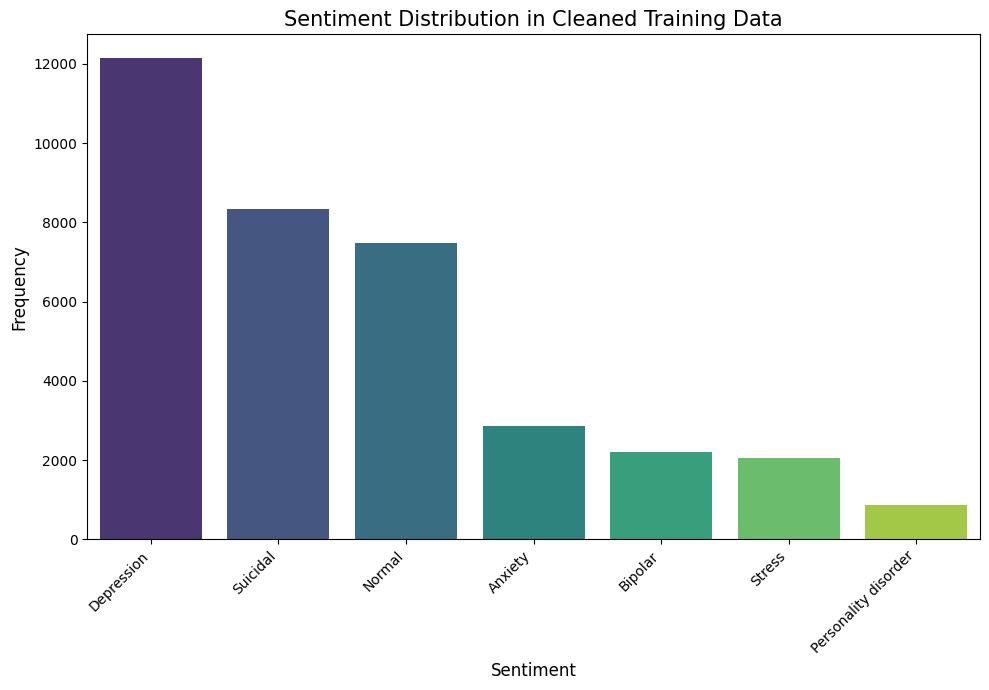

In [ ]:
print("\n Exploratory Data Analysis on Cleaned Training Data")

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Sentiment Frequency Bar Chart

if not y_train_cleaned.empty:
    plt.figure(figsize=(10, 7))
    sentiment_counts_train = y_train_cleaned.map(id_to_label).value_counts()
    sns.barplot(x=sentiment_counts_train.index, y=sentiment_counts_train.values, hue=sentiment_counts_train.index, palette="viridis", legend = False)
    plt.title('Sentiment Distribution in Cleaned Training Data', fontsize=15)
    plt.ylabel('Frequency', fontsize=12)
    plt.xlabel('Sentiment', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sentiment_distribution_train_cleaned_bar.png'))
    plt.show()


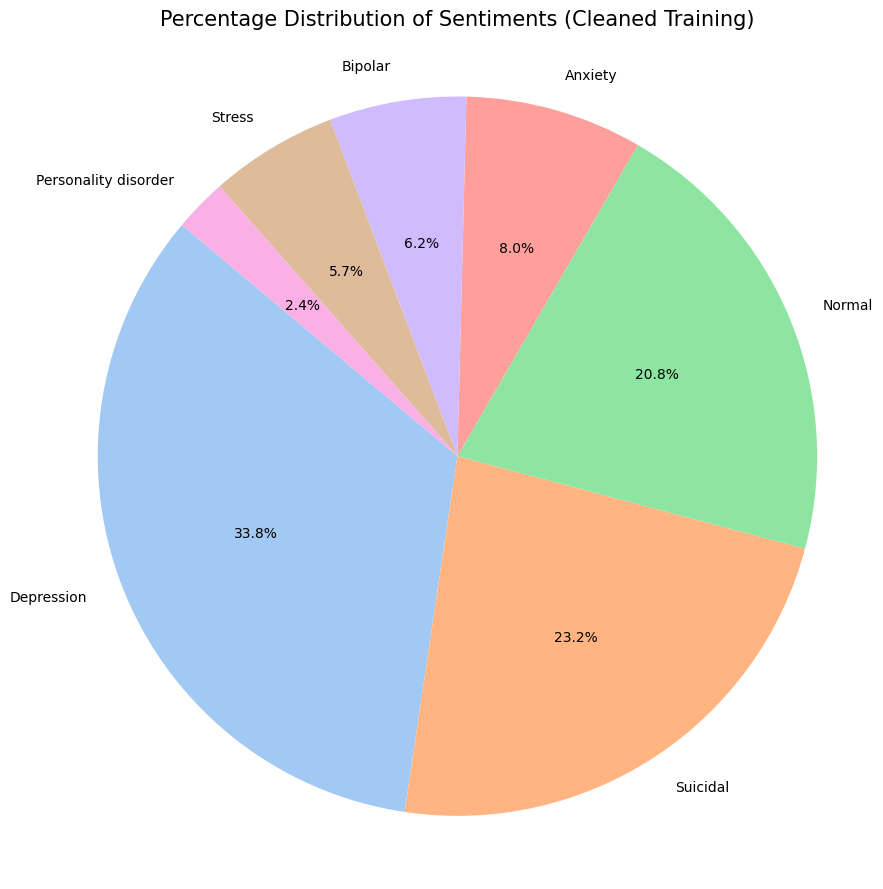

In [26]:
# Sentiment Frequency Pie Chart
plt.figure(figsize=(9, 9))
plt.pie(sentiment_counts_train, labels=sentiment_counts_train.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'), textprops={'fontsize': 10})
plt.title('Percentage Distribution of Sentiments (Cleaned Training)', fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sentiment_distribution_train_cleaned_pie.png'))
plt.show()